In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("data/online_retail_II.xlsx")

In [3]:
df.shape

(525461, 8)

In [4]:
df["InvoiceDate"].dtype

dtype('<M8[us]')

In [5]:
df = df.drop_duplicates()

In [6]:
df.shape

(518596, 8)

In [7]:
df=df.dropna(subset=["Customer ID"])

In [8]:
df.shape

(410763, 8)

In [9]:
df[(df["Quantity"]<0) & (df["Invoice"].astype(str).str.startswith("C"))].shape

(9816, 8)

In [10]:
df_obs=df[df["InvoiceDate"]< pd.Timestamp("2010-08-31")]

In [11]:
df_obs.shape

(250422, 8)

In [12]:
df_obs["Revenue"]=df_obs["Quantity"] * df_obs["Price"]

In [13]:
monetary=df_obs.groupby("Customer ID")["Revenue"].sum()

In [14]:
df_obs.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [15]:
frequency = df_obs.groupby("Customer ID")["Invoice"].nunique()

In [16]:
frequency.head(10)

Customer ID
12346.0    13
12349.0     3
12355.0     1
12358.0     2
12359.0     7
12360.0     4
12361.0     2
12362.0     1
12366.0     1
12368.0     1
Name: Invoice, dtype: int64

In [17]:
last_purchase=df_obs.groupby("Customer ID")["InvoiceDate"].max()

In [18]:
last_purchase

Customer ID
12346.0   2010-06-30 11:22:00
12349.0   2010-05-18 09:57:00
12355.0   2010-05-21 11:59:00
12358.0   2010-06-07 12:28:00
12359.0   2010-06-22 10:24:00
                  ...        
18281.0   2010-05-11 10:49:00
18283.0   2010-08-19 13:04:00
18285.0   2010-02-17 10:24:00
18286.0   2010-08-20 11:57:00
18287.0   2010-05-17 11:55:00
Name: InvoiceDate, Length: 3385, dtype: datetime64[us]

In [19]:
recency=(pd.Timestamp("2010-08-31") - last_purchase).dt.days

In [20]:
recency

Customer ID
12346.0     61
12349.0    104
12355.0    101
12358.0     84
12359.0     69
          ... 
18281.0    111
18283.0     11
18285.0    194
18286.0     10
18287.0    105
Name: InvoiceDate, Length: 3385, dtype: int64

In [21]:
first_purchase=df_obs.groupby("Customer ID")["InvoiceDate"].min()

In [22]:
tenure=(pd.Timestamp("2010-08-31") - first_purchase).dt.days

In [23]:
tenure

Customer ID
12346.0    259
12349.0    269
12355.0    101
12358.0    265
12359.0    268
          ... 
18281.0    111
18283.0    192
18285.0    194
18286.0    257
18287.0    272
Name: InvoiceDate, Length: 3385, dtype: int64

In [24]:
df_obs["is_cancel"]=df_obs["Invoice"].astype(str).str.startswith("C")

In [25]:
cancel_rate=df_obs.groupby("Customer ID")["is_cancel"].mean()

In [26]:
cancel_rate

Customer ID
12346.0    0.232558
12349.0    0.096154
12355.0    0.000000
12358.0    0.000000
12359.0    0.044444
             ...   
18281.0    0.000000
18283.0    0.000000
18285.0    0.000000
18286.0    0.042857
18287.0    0.018182
Name: is_cancel, Length: 3385, dtype: float64

In [27]:
customers = pd.concat([monetary, frequency, recency, tenure, cancel_rate],axis=1)

In [28]:
customers.columns = ["monetary", "frequency", "recency", "tenure", "cancel_rate"]

In [29]:
customers.head()

,monetary,frequency,recency,tenure,cancel_rate
Customer ID,,,,,
12346.0,-46.24,13,61,259,0.232558
12349.0,1244.37,3,104,269,0.096154
12355.0,488.21,1,101,101,0.000000
12358.0,1697.93,2,84,265,0.000000
12359.0,1918.03,7,69,268,0.044444


In [30]:
df_label = df[df["InvoiceDate"] >= pd.Timestamp("2010-08-31")]

In [31]:
df_label.shape

(160341, 8)

In [32]:
returning_customers=df_label["Customer ID"].unique()

In [33]:
returning_customers

array([15955., 16975., 12423., ..., 15192., 15211., 17530.], shape=(3040,))

In [34]:
customers["target"]=customers.index.isin(returning_customers).astype(int)

In [35]:
customers["target"].head()

Customer ID
12346.0    1
12349.0    1
12355.0    0
12358.0    1
12359.0    1
Name: target, dtype: int64

In [36]:
customers

,monetary,frequency,recency,tenure,cancel_rate,target
Customer ID,,,,,,
12346.0,-46.24,13,61,259,0.232558,1
12349.0,1244.37,3,104,269,0.096154,1
12355.0,488.21,1,101,101,0.000000,0
12358.0,1697.93,2,84,265,0.000000,1
12359.0,1918.03,7,69,268,0.044444,1
...,...,...,...,...,...,...
18281.0,120.32,1,111,111,0.000000,0
18283.0,424.02,4,11,192,0.000000,1
18285.0,427.00,1,194,194,0.000000,0


In [37]:
n_products=df_obs.groupby("Customer ID")["StockCode"].nunique()
customers["n_products"] = n_products
customers.head()

,monetary,frequency,recency,tenure,cancel_rate,target,n_products
Customer ID,,,,,,,
12346.0,-46.24,13,61,259,0.232558,1,28
12349.0,1244.37,3,104,269,0.096154,1,49
12355.0,488.21,1,101,101,0.000000,0,22
12358.0,1697.93,2,84,265,0.000000,1,34
12359.0,1918.03,7,69,268,0.044444,1,82


In [38]:
df_h1 = df_obs[df_obs["InvoiceDate"] < pd.Timestamp("2010-04-15")]
df_h2 = df_obs[df_obs["InvoiceDate"] >= pd.Timestamp("2010-04-15")]

In [39]:
spend_h1 = df_h1.groupby("Customer ID")["Revenue"].sum()
spend_h2 = df_h2.groupby("Customer ID")["Revenue"].sum()

In [40]:
trend = spend_h2.reindex(customers.index, fill_value=0) - spend_h1.reindex(customers.index,fill_value=0)

In [41]:
customers["trend"] = trend

In [42]:
X = customers.drop(columns="target")
y = customers["target"]

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=23, stratify=y)

In [44]:
X_train.shape

(2708, 7)

In [45]:
y_train.mean()

np.float64(0.603397341211226)

In [46]:
y_test.mean()

np.float64(0.6026587887740029)

In [47]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy.score(X_test, y_test)

0.6026587887740029

In [48]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
logreg.score(X_test, y_test)

0.6838995568685377

              precision    recall  f1-score   support

           0       0.60      0.61      0.60       269
           1       0.74      0.74      0.74       408

    accuracy                           0.69       677
   macro avg       0.67      0.67      0.67       677
weighted avg       0.69      0.69      0.69       677

0.7506013557839493


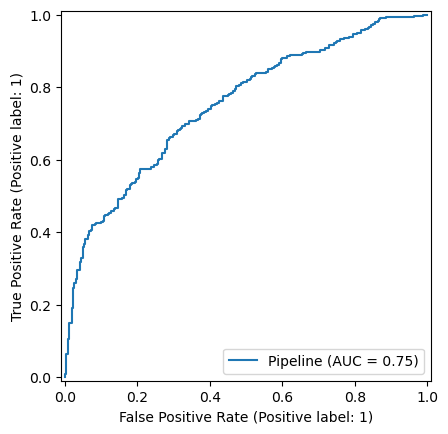

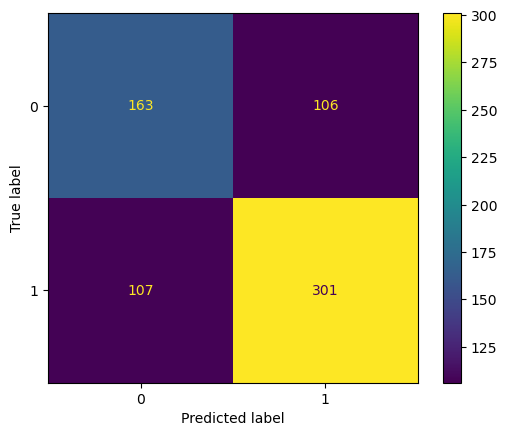

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,roc_auc_score,RocCurveDisplay,ConfusionMatrixDisplay
my_pipeline = Pipeline(steps=[
    ("scaler",StandardScaler()),
    ("model",LogisticRegression(max_iter=1000))
])
my_pipeline.fit(X_train,y_train)
y_pred=my_pipeline.predict(X_test)
confusion_matrix(y_test, y_pred)
print(classification_report(y_test,y_pred))
pred_prob=my_pipeline.predict_proba(X_test)
print(roc_auc_score(y_test,pred_prob[:,1]))
RocCurveDisplay.from_estimator(my_pipeline, X_test, y_test)
ConfusionMatrixDisplay.from_estimator(my_pipeline, X_test, y_test)

[ 0.50170404  0.58311313 -0.50270723  0.32623136 -0.13086865  0.35936548
  0.28822923]


Text(0.5, 1.0, 'First row of coefficients in Logistic Regression')

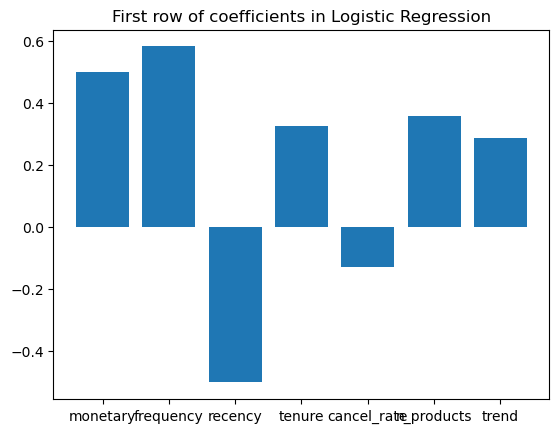

In [50]:
print(my_pipeline["model"].coef_[0])
plt.bar(X.columns,my_pipeline["model"].coef_[0])
plt.title("First row of coefficients in Logistic Regression")

In [56]:
from sklearn.ensemble import RandomForestClassifier
randforest = RandomForestClassifier(n_estimators=1000,random_state=23,max_depth=50,min_samples_leaf=2)
randforest.fit(X_train,y_train)
randforest.score(X_train,y_train)

0.9745199409158051

In [52]:

from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=23)
xgb.fit(X_train,y_train)
xgb.score(X_test,y_test)


0.6395864106351551

In [53]:
df_obs.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,is_cancel
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,False


In [54]:
print(my_pipeline.score(X_test, y_test))
print(roc_auc_score(y_test, my_pipeline.predict_proba(X_test)[:, 1]))

0.6853766617429837
0.7506013557839493


In [55]:
print(X.shape,X.columns)

(3385, 7) Index(['monetary', 'frequency', 'recency', 'tenure', 'cancel_rate',
       'n_products', 'trend'],
      dtype='str')
